# Types of Learning in Machine Learning
In this notebook, we will explore the main types of learning in machine learning, including **Supervised Learning**, **Unsupervised Learning**, **Reinforcement Learning**, and **Transfer Learning**. For each type, we'll provide explanations and simple Python examples.

## 1. Supervised Learning
**Definition:** The model learns from labeled data, where each input has a corresponding output.

**Examples:**
- Classification (e.g., Spam Detection)
- Regression (e.g., Predicting House Prices)

**Key Applications:** Image recognition, fraud detection, etc.

In [1]:
# Example: Supervised Learning (Classification)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
data = load_iris()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Decision Tree Classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Predict and calculate accuracy
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


## 2. Unsupervised Learning
**Definition:** The model learns patterns or structures from unlabeled data.

**Examples:**
- Clustering (e.g., Customer Segmentation)
- Dimensionality Reduction (e.g., PCA)

**Key Applications:** Anomaly detection, market basket analysis, etc.

C:\Users\bahareh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\bahareh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


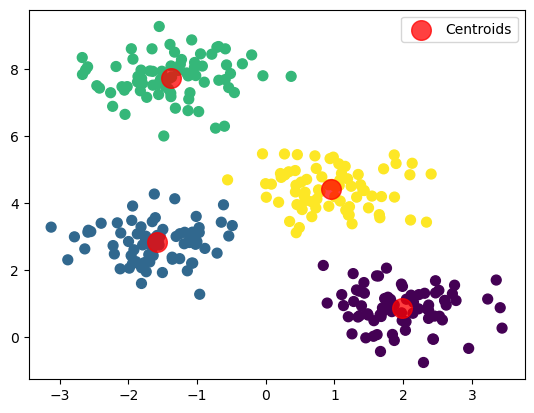

In [3]:
# Example: Unsupervised Learning (Clustering)
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create a synthetic dataset
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4)
y_kmeans = kmeans.fit_predict(X)

# Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, label='Centroids')
plt.legend()
plt.show()

## 3. Reinforcement Learning
**Definition:** The model learns by interacting with the environment and receiving rewards or penalties.

**Examples:**
- Game Playing (e.g., AlphaGo)
- Robotics (e.g., Navigation Tasks)

**Key Applications:** Autonomous systems, resource optimization, etc.

In [7]:
pip install gym

     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
      --------------------------------------- 10.2/721.7 kB ? eta -:--:--
     - ----------------------------------- 30.7/721.7 kB 660.6 kB/s eta 0:00:02
     - ----------------------------------- 30.7/721.7 kB 660.6 kB/s eta 0:00:02
     - ----------------------------------- 30.7/721.7 kB 660.6 kB/s eta 0:00:02
     --- --------------------------------- 61.4/721.7 kB 252.2 kB/s eta 0:00:03
     ---- -------------------------------- 92.2/721.7 kB 327.7 kB/s eta 0:00:02
     ---- -------------------------------- 92.2/721.7 kB 327.7 kB/s eta 0:00:02
     ----- ------------------------------ 112.6/721.7 kB 297.7 kB/s eta 0:00:03
     ------- ---------------------------- 143.4/721.7 kB 341.3 kB/s eta 0:00:02
     ------- ---------------------------- 153.6/721.7 kB 353.1 kB/s eta 0:00:02
     ------- ---------------------------- 153.6/721.7 kB 353.1 kB/s eta 0:00:02
     ------- ---------------------------- 153.6/721.7

In [13]:
pip install pygame


  Obtaining dependency information for pygame from https://files.pythonhosted.org/packages/d2/55/ca3eb851aeef4f6f2e98a360c201f0d00bd1ba2eb98e2c7850d80aabc526/pygame-2.6.1-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB 330.3 kB/s eta 0:00:33
   ---------------------------------------- 0.0/10.6 MB 445.2 kB/s eta 0:00:24
   ---------------------------------------- 0.0/10.6 MB 445.2 kB/s eta 0:00:24
   ---------------------------------------- 0.0/10.6 MB 196.9 kB/s eta 0:00:54
   ---------------------------------------- 0.1/10.6 MB 273.8 kB/s eta 0:00:39
   ---------------------------------------- 0.1/10.6 MB 327.7 kB/s eta 0:00:33
   ---------------------------------------- 0.1/10.6 MB 327.7 kB/s eta 0:00:33
   ---------------------------------------- 0.1/10.6 MB 281.0 kB/s eta 0:00:38
    --------------------------------------- 0.1/10.6 MB 341.3 kB/s eta 0:00:31
    ---------

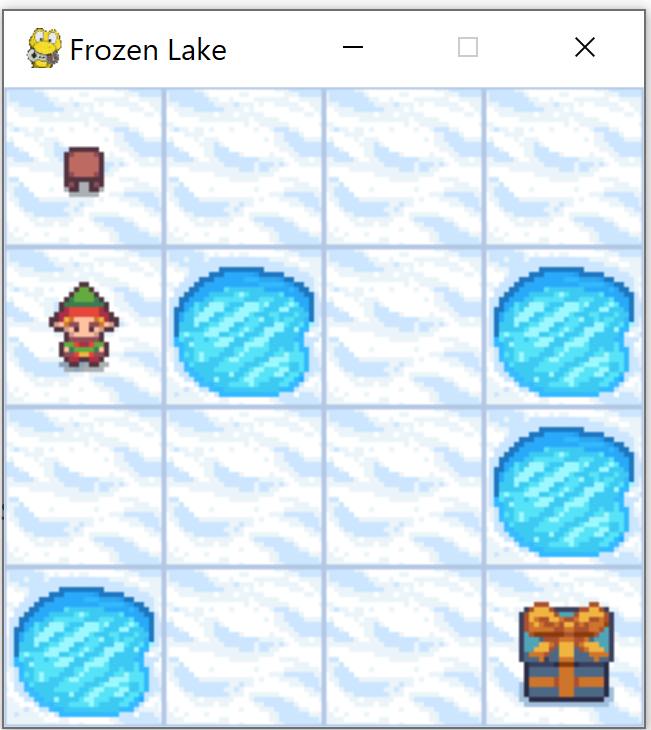

In [1]:
import gym
import numpy as np

# Create the FrozenLake environment with render_mode
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")

# Q-Table settings
state_size = env.observation_space.n
action_size = env.action_space.n
q_table = np.zeros((state_size, action_size))

# Q-Learning algorithm parameters
learning_rate = 0.8
discount_factor = 0.95
epsilon = 1.0  # Probability of choosing a random action
epsilon_decay = 0.995
episodes = 1000

# Train the agent
for episode in range(episodes):
    state = env.reset()[0]
    done = False
    
    while not done:
        # Choose an action (using Epsilon-Greedy strategy)
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state, :])
        
        # Perform the action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Update the Q-Table
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_factor * np.max(q_table[next_state, :]) - q_table[state, action]
        )
        
        state = next_state
    
    # Reduce epsilon to decrease random behavior
    epsilon = max(0.1, epsilon * epsilon_decay)

print("Training completed!")

# Test the trained agent
state = env.reset()[0]
env.render()

done = False
while not done:
    action = np.argmax(q_table[state, :])
    next_state, reward, terminated, truncated, _ = env.step(action)
    env.render()
    done = terminated or truncated
    state = next_state

env.close()


C:\Users\bahareh\anaconda3\Lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


KeyboardInterrupt: 

## 4. Transfer Learning
**Definition:** Knowledge learned in one problem is applied to a related problem.

**Example:** Using a pretrained image recognition model for medical image classification.

**Key Applications:** Medical imaging, natural language processing, etc.

In [6]:
pip install tensorflow --upgrade


^C
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install h5py numpy


Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install tensorflow


^C
Note: you may need to restart the kernel to use updated packages.


In [10]:
from tensorflow.keras.applications import VGG16

# Load the VGG16 model with pretrained weights from ImageNet
model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model.summary()


ModuleNotFoundError: No module named 'tensorflow'

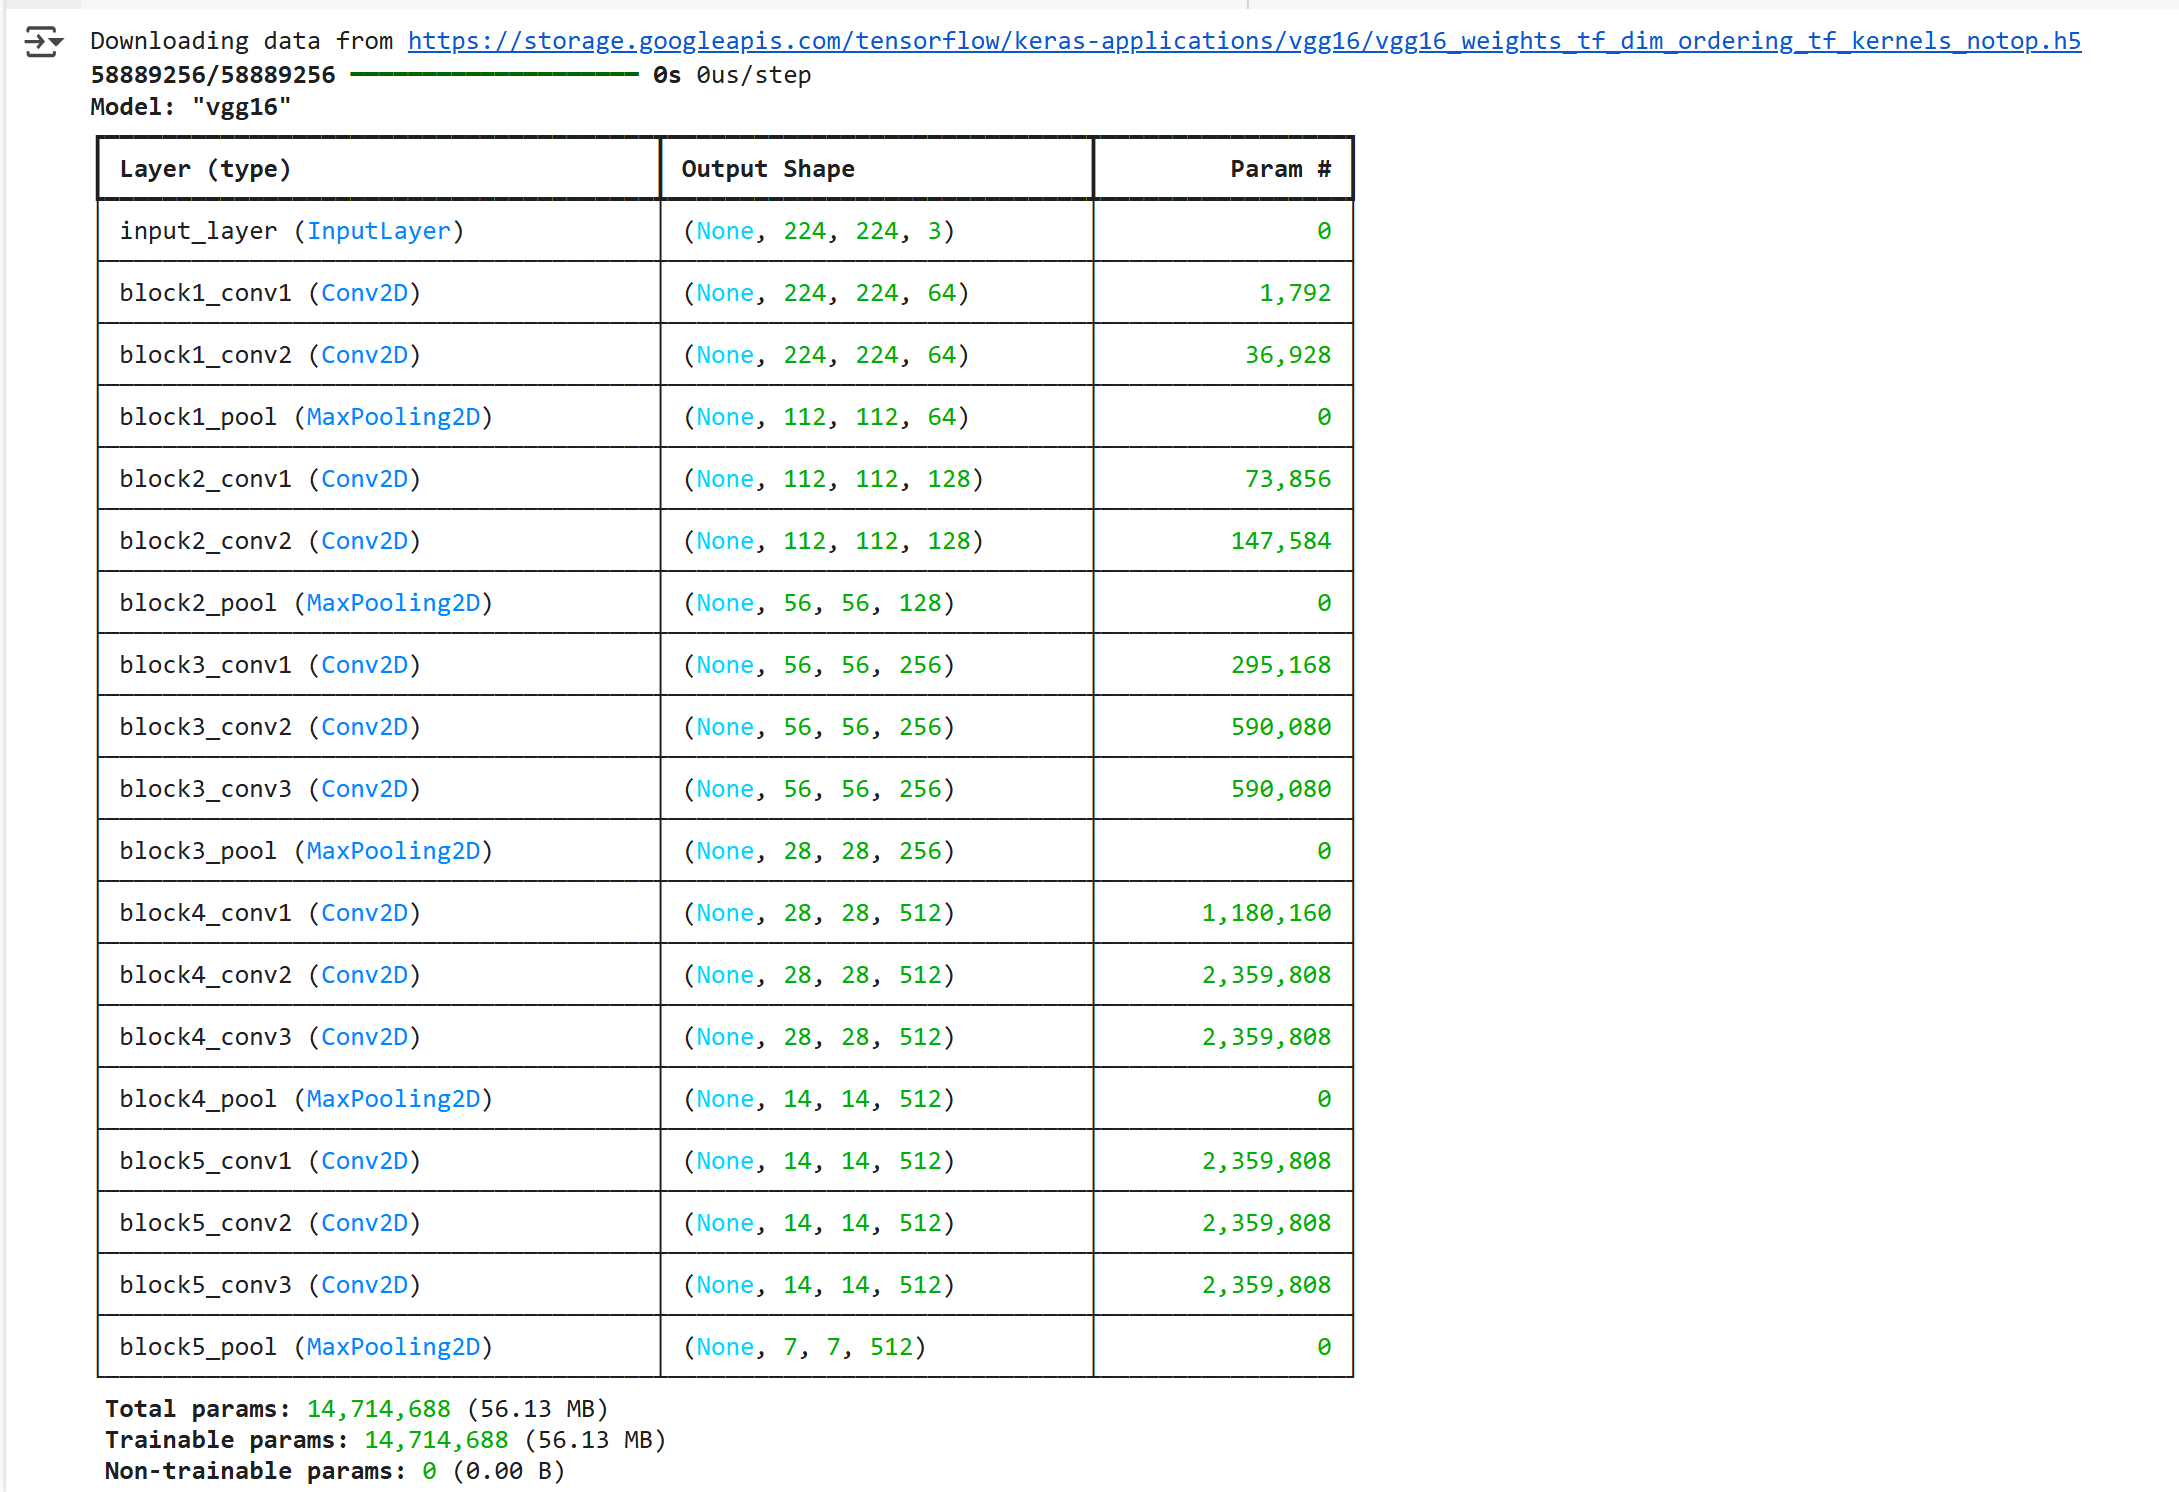

## Conclusion
In this notebook, we covered the main types of learning in machine learning:

- **Supervised Learning**: Learning from labeled data.
- **Unsupervised Learning**: Finding patterns in unlabeled data.
- **Reinforcement Learning**: Learning by interaction with the environment.
- **Transfer Learning**: Reusing knowledge from a pretrained model.

These concepts form the foundation of machine learning and are widely used in various applications.